<a href="https://colab.research.google.com/github/ThomasAlbin/Space-Science-With-Python/blob/main/2026/00_SPICE_time.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SPICE Lecture 00: Time

In this notebook we will cover some SPICE basics that are related to time! Do not worry about SPICE's complexity in regards of time systems. Mostly you will use:

- Ephemeris Time (ET, respectively called in SPICE TDB)
- Terrestial Barycenter Time (TBT)
- Spacecraft Clock

Here, we will take a look at all three topics.

In [1]:
import spiceypy as spice
import numpy as np

## SPICE needs kernels!

SPICE is kernel-based, and kernels are files that contain miscellaneous information e.g. about a spacecraft, time systems, reference frames etc. Some things are "pre-installed", but most of the time we need to download kernels to get things running.

Let's see what happens when we try to get things running without any kernels

In [4]:
# str2et converts a "time string" to ET. If we do not provide any time system information, the string is interpreted as, according to the documentation:
#   Consider the string
#
#      1988 June 13, 3:29:48
#
#   There is nothing in this string to indicate what time system
#   the date and time belong to. Moreover, there is nothing to
#   indicate whether the time is based on a 24-hour clock or
#   twelve hour clock.
#
#   In the absence of such indicators, the default interpretation
#   of this string is to regard the time of day to be a time on
#   a 24-hour clock in the UTC time system. The date is a date
#   on the Gregorian Calendar (this is the calendar used in nearly
#   all western societies).
spice.str2et("1988 June 13, 3:29:48")

SpiceNOLEAPSECONDS: 
================================================================================

Toolkit version: CSPICE_N0067

SPICE(NOLEAPSECONDS) --

The variable that points to the leapseconds (DELTET/DELTA_AT) could not be located in the kernel pool.  It is likely that the leapseconds kernel has not been loaded.

str2et_c --> STR2ET --> TTRANS

================================================================================

We get the error: *The variable that points to the leapseconds (DELTET/DELTA_AT) could not be located in the kernel pool.  It is likely that the leapseconds kernel has not been loaded.*

In [6]:
# Let's download the leapseconds kernel and load it. This will allow us to use the UTC time system in our time strings.
# First we create a directory to store our kernels in, and then we download the leapseconds kernel from the NAIF website.
# Finally, we load the kernel into our Python session.
from pathlib import Path
data_dir = Path("../data")
data_dir.mkdir(exist_ok=True)

In [7]:
# We download the kernel from the generic directory: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/
# The leapseconds kernel is located at: https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls
import urllib.request
leapseconds_url = "https://naif.jpl.nasa.gov/pub/naif/generic_kernels/lsk/naif0012.tls"
leapseconds_path = data_dir / "naif0012.tls"
urllib.request.urlretrieve(leapseconds_url, leapseconds_path) 

(PosixPath('../data/naif0012.tls'),
 <http.client.HTTPMessage at 0xffff841ea360>)

In [8]:
# Load the kernel into our Python session.
spice.furnsh(str(leapseconds_path))

In [9]:
# Retesting the code from above
spice.str2et("1988 June 13, 3:29:48")

-364552155.81541353

In [40]:
# Nice! Note that we get a negative number since the input time is before the J2000 epoch.
spice.str2et("2000-01-01T12:00:00")

64.18392728473108

WHAT. I thought this was the J2000 epoch. Why is it not zero?
The J2000 epoch is defined as 2000-01-01T12:00:00 in the TDT (TT) time system.

The US Naval Observatory (https://aa.usno.navy.mil/faq/TT) states:

> Terrestrial Time (TT) is a time scale established by the International Astronomical Union (IAU) to serve as the independent argument for apparent geocentric ephemerides. That is, TT is used for the prediction or recording of the positions of celestial bodies as measured by an observer on Earth. It is the successor to Ephemeris Time (ET), but is based on the Système International (SI) second.
> 
> Terrestrial Time is effectively equal to International Atomic Time (TAI) plus 32.184 seconds exactly: TT = TAI + 32.184
> 
> The epoch designated "J2000.0" is specified as Julian date 2451545.0 TT, or 2000 January 1, 12h TT. This epoch can also be expressed as 2000 January 1, 11:59:27.816 TAI or 2000 January 1, 11:58:55.816 UTC. ´´´

... so ... the ET for J2000 @TDT shall be 0, right?

In [41]:
spice.str2et("2000-01-01 12:00:00 TDT")

-7.273677619130569e-05

Well... no... J2000 is IN FACT based on TDT, but converting it to ET, that is TDB (!) we have a slight offet of around 72 microseconds.

If you are not a high-precision astronomer, well then you can ignore these almost insignificant differences.

In [42]:
# But let's be sure though!
spice.str2et("2000-01-01 12:00:00 TDB")

0.0

## The unitim function ...

... is pretty powerful and your second function in your asset box. You can set any epoch as an input (note: an epoch is seconds-based!) and then you can convert it from one time system to any pre-defined SPICE system.

In [43]:
# "Proof" that TT and TDT are the same time system.
spice.unitim(1000, "TT", "TDT")

1000.0

In [44]:
# The difference between TDB and TDT is on the order of milliseconds, so we should not expect to see a large difference here.
spice.unitim(10000, "TDT", "TDB")

9999.99993061425

## The everlasting changes
TDT and TDB are drifting apart. Let's visualise it!

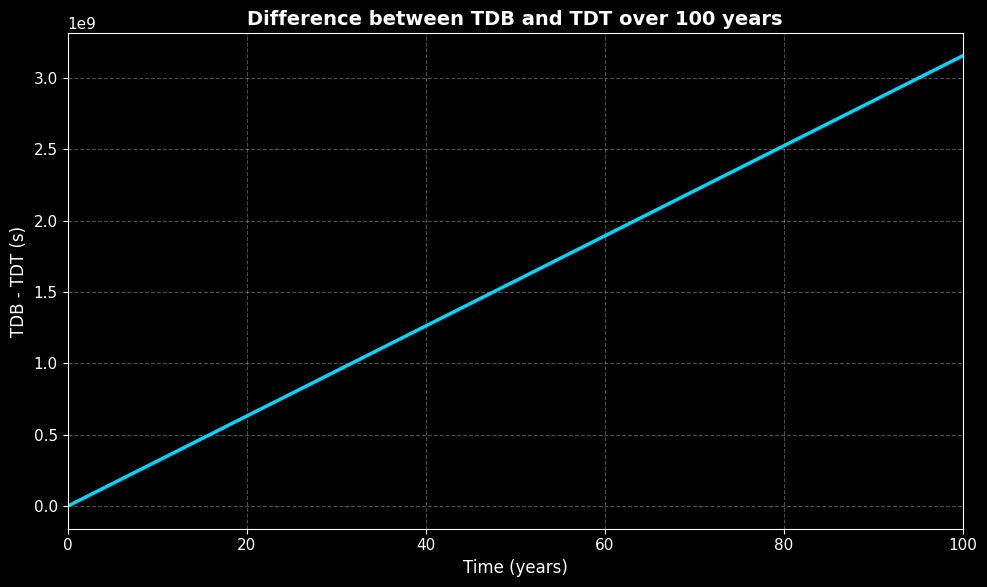

In [50]:
# Visualisation of the difference between TDB and TDT over a 100 year period.
import matplotlib.pyplot as plt
plt.style.use('dark_background')
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 11

times = np.linspace(0, 100 * 365.25 * 24 * 3600, 1000)
tdb_minus_tdt = [spice.unitim(int(t), "TDT", "TDB") for t in times]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(times / (365.25 * 24 * 3600), tdb_minus_tdt, linewidth=2.5, color='#00d4ff')
ax.set_xlabel(r"Time (years)", fontsize=12)
ax.set_ylabel(r"TDB - TDT (s)", fontsize=12)
ax.set_title(r"Difference between TDB and TDT over 100 years", fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

## Spacecraft Clock (SCLK)

In a final step we are going to take a look at SCLKs. Let's consider Cassini CDA data; so called time-of-flight spectra that revealed different chemical compositions of dust particles in the Saturnian System.

Thanks to these scientific measurements, we were able to determine the composition of interstellar dust and reveal the liquid ocean within Enceladus.

Currently (May 2026), there are ~15.000 spectra classified manually; and available here: https://huggingface.co/datasets/CosmicDustGroup/cassini-cda-spectra

We won't go too much into detail... one class, "type 4" is a pure mineral spectra and one of the corresponding measurements was: at SCLK

> 1481851286

... but which time is it?

In [55]:
# First we download the Cassini SCLK kernel from the NAIF website. The SCLK kernel is located at:
sclk_url = "https://naif.jpl.nasa.gov/pub/naif/CASSINI/kernels/sclk/cas00172.tsc"
sclk_path = data_dir / "cas00172.tsc"
urllib.request.urlretrieve(sclk_url, sclk_path)

spice.furnsh(str(sclk_path))

In [ ]:
# Now we convert the SCLK to UTC TDT
cda_measuremnt_sclk = 1481851286

# We use the function: scs2e
# However, it requires an "NAIF ID Code" from the spacecraft?!

### NAIF ID Codes

NAIF ID Codes are internal codes for planets, barycenters, spacecraft etc. and are like "primary keys" of a database. One can extract the IDs either from kernels or one can take a look at the overview website: https://naif.jpl.nasa.gov/pub/naif/toolkit_docs/C/req/naif_ids.html

Cassini's ID is -82

In [75]:
cda_measuremnt_et = spice.scs2e(sc=-82, sclkch=str(cda_measuremnt_sclk))

# And now convert it in a "human readable" format
# UTC is default! Remember the ~64 s shift to TT/TDB
cda_measuremnt_utc_str = spice.timout(cda_measuremnt_et, "YYYY-MON-DD HR:MN:SC ::UTC")

print(cda_measuremnt_utc_str)

2004-DEC-16 00:55:36


In [ ]:
# Another way is to use the function: etcal
cda_measuremnt_utc_str_2 = spice.etcal(cda_measuremnt_et)

print(cda_measuremnt_utc_str_2)

# etcal does not consider leapseconds and such. My recommendation: nice for a quick check, but use timout for anything more
# production-ready.

2004 DEC 16 00:56:40.536
